# Clinical SHAP Explainability

In [1]:
import sys
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

sys.path.insert(0, r"C:\FYP\src")
from utils.config import (
    TABULAR_CLEAN_PATH, CHECKPOINTS_CLINICAL_FINAL_DIR,
    RESULTS_CLINICAL_DIR, EVAL_CLINICAL_DIR, ensure_dirs, RANDOM_SEED,
)

ensure_dirs()
pd.set_option("display.width", 120)
print(f"shap {shap.__version__}")
print("Imports OK")


shap 0.52.0
Imports OK


## Load the clinical branch (read-only)

In [2]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge


class MICE_CA19_9Imputer:
    PREDICTORS = ["creatinine", "LYVE1", "REG1B", "TFF1", "age"]
    TARGET = "plasma_CA19_9"

    def __init__(self, random_state=RANDOM_SEED):
        self.imputer = IterativeImputer(estimator=BayesianRidge(), random_state=random_state)

    def fit(self, train_df):
        self.imputer.fit(train_df[self.PREDICTORS + [self.TARGET]])
        return self

    def transform(self, target_df):
        out = target_df.copy()
        out[self.TARGET] = self.imputer.transform(out[self.PREDICTORS + [self.TARGET]])[:, -1]
        return out


clinical_model = joblib.load(CHECKPOINTS_CLINICAL_FINAL_DIR / "model.pkl")
clinical_imputer = joblib.load(CHECKPOINTS_CLINICAL_FINAL_DIR / "ca19_9_imputer.pkl")

with open(CHECKPOINTS_CLINICAL_FINAL_DIR / "model_card.json") as f:
    clinical_model_card = json.load(f)

print(f"Model: {type(clinical_model).__name__}, feature_names_in_={list(clinical_model.feature_names_in_)}")
print(f"Trained on {clinical_model_card['trained_on']}, n_patients={clinical_model_card['n_patients']}")


Model: XGBClassifier, feature_names_in_=[np.str_('creatinine'), np.str_('LYVE1'), np.str_('REG1B'), np.str_('TFF1'), np.str_('plasma_CA19_9'), np.str_('age'), np.str_('sex')]
Trained on 2026-07-16, n_patients=590


## Build the exact matrix the model sees at inference

In [3]:
df = pd.read_csv(TABULAR_CLEAN_PATH)
assert df.shape[0] == 590, f"expected 590 rows, got {df.shape[0]}"

feature_order = list(clinical_model.feature_names_in_)
ca19_9_missing_mask = df["plasma_CA19_9"].isna().to_numpy()
print(f"plasma_CA19_9 originally missing: {ca19_9_missing_mask.sum()} / {len(df)} rows")

df_imputed = clinical_imputer.transform(df)
assert df_imputed["plasma_CA19_9"].isna().sum() == 0, "imputer left NaNs behind"

X_imputed = df_imputed[feature_order].reset_index(drop=True)
y = df["target_binary"].to_numpy()

print(f"X_imputed shape: {X_imputed.shape}, columns: {list(X_imputed.columns)}")
X_imputed.head()


plasma_CA19_9 originally missing: 240 / 590 rows


X_imputed shape: (590, 7), columns: ['creatinine', 'LYVE1', 'REG1B', 'TFF1', 'plasma_CA19_9', 'age', 'sex']


,creatinine,LYVE1,REG1B,TFF1,plasma_CA19_9,age,sex
0,1.83222,0.893219,52.94884,654.282174,11.70000,33,0
1,0.97266,2.037585,94.46703,209.488250,527.61519,81,0
2,0.78039,0.145589,102.36600,461.141000,7.00000,51,1
3,0.70122,0.002805,60.57900,142.950000,8.00000,61,1
4,0.21489,0.000860,65.54000,41.088000,9.00000,62,1


## TreeExplainer, raw log-odds space

In [4]:
explainer = shap.TreeExplainer(clinical_model, feature_perturbation="tree_path_dependent")
shap_values = explainer.shap_values(X_imputed)
shap_values = np.asarray(shap_values)
if shap_values.ndim == 3:
    # some shap/xgboost version combos return (n_outputs, n_rows, n_features) or (n_rows, n_features, n_outputs)
    shap_values = shap_values[..., -1] if shap_values.shape[-1] == 2 else shap_values[-1]

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = np.asarray(expected_value).reshape(-1)[-1]
expected_value = float(expected_value)

print(f"shap_values shape: {shap_values.shape}")
print(f"expected_value (base value, log-odds): {expected_value:.6f}")
assert shap_values.shape == (590, 7), f"expected (590, 7), got {shap_values.shape}"


shap_values shape: (590, 7)
expected_value (base value, log-odds): -0.761708


## Sanity check: additivity (hard stop on failure)

In [5]:
raw_margin_pred = clinical_model.predict(X_imputed, output_margin=True)
reconstructed = expected_value + shap_values.sum(axis=1)
max_abs_error = float(np.max(np.abs(reconstructed - raw_margin_pred)))

passes = max_abs_error < 1e-4
print(f"Additivity check: {'PASS' if passes else 'FAIL'} (max abs error = {max_abs_error:.8f})")
assert passes, (
    f"Additivity check FAILED (max abs error {max_abs_error:.8f} >= 1e-4) -- "
    "stopping before producing any plots from broken SHAP values."
)


Additivity check: PASS (max abs error = 0.00000477)


## Save SHAP values

In [6]:
shap_values_df = pd.DataFrame(shap_values, columns=feature_order)
shap_values_path = RESULTS_CLINICAL_DIR / "shap_values.csv"
shap_values_df.to_csv(shap_values_path, index=False)

shap_meta_path = RESULTS_CLINICAL_DIR / "shap_values_meta.json"
with open(shap_meta_path, "w") as f:
    json.dump(
        {
            "expected_value": expected_value,
            "output_space": "raw_margin_log_odds",
            "feature_order": feature_order,
            "n_rows": int(shap_values_df.shape[0]),
            "additivity_max_abs_error": max_abs_error,
        },
        f,
        indent=2,
    )

print(f"Saved {shap_values_path} ({shap_values_df.shape})")
print(f"Saved {shap_meta_path}")


Saved C:\FYP\results\clinical\shap_values.csv ((590, 7))
Saved C:\FYP\results\clinical\shap_values_meta.json


## Figures

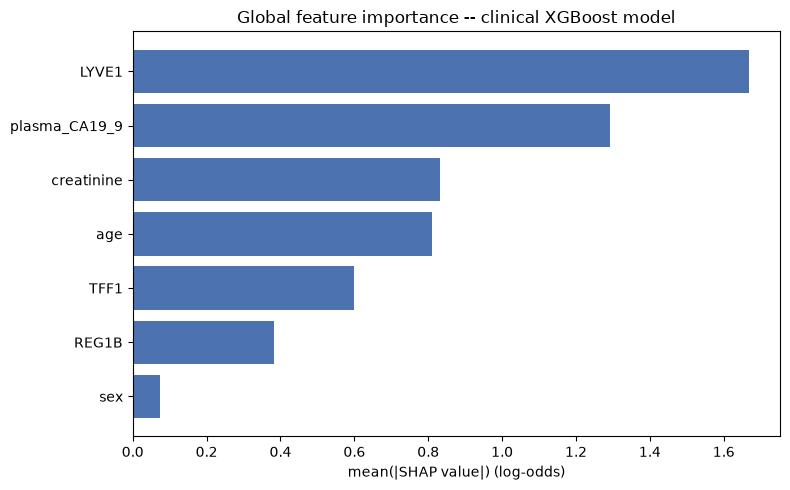

LYVE1            1.668855
plasma_CA19_9    1.292999
creatinine       0.832104
age              0.809623
TFF1             0.599364
REG1B            0.382138
sex              0.072649
dtype: float32

In [7]:
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_order).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(mean_abs_shap.index, mean_abs_shap.values, color="#4C72B0")
ax.set_xlabel("mean(|SHAP value|) (log-odds)")
ax.set_title("Global feature importance -- clinical XGBoost model")
fig.tight_layout()
fig.savefig(EVAL_CLINICAL_DIR / "shap_global_importance.png", dpi=150)
plt.show()

mean_abs_shap.sort_values(ascending=False)


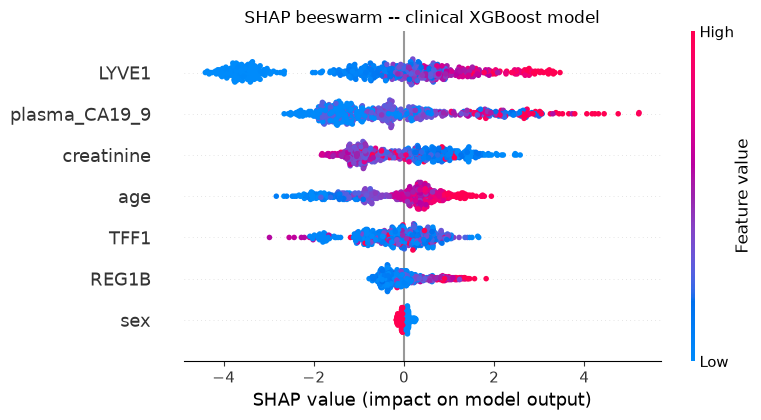

In [8]:
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_imputed, feature_names=feature_order, show=False)
plt.title("SHAP beeswarm -- clinical XGBoost model")
plt.tight_layout()
plt.savefig(EVAL_CLINICAL_DIR / "shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()


### CA19-9 dependence plot -- imputed rows marked

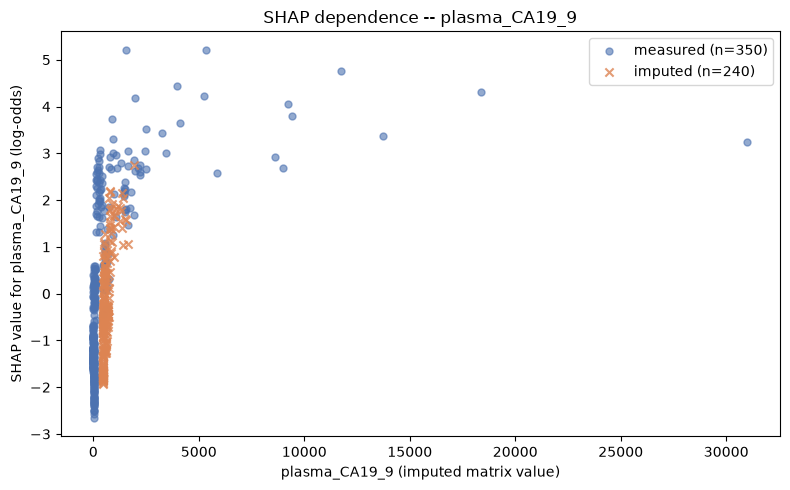

In [9]:
ca19_9_idx = feature_order.index("plasma_CA19_9")
ca19_9_values = X_imputed["plasma_CA19_9"].to_numpy()
ca19_9_shap = shap_values[:, ca19_9_idx]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    ca19_9_values[~ca19_9_missing_mask], ca19_9_shap[~ca19_9_missing_mask],
    c="#4C72B0", label=f"measured (n={(~ca19_9_missing_mask).sum()})", alpha=0.6, s=25,
)
ax.scatter(
    ca19_9_values[ca19_9_missing_mask], ca19_9_shap[ca19_9_missing_mask],
    c="#DD8452", marker="x", label=f"imputed (n={ca19_9_missing_mask.sum()})", alpha=0.8, s=35,
)
ax.set_xlabel("plasma_CA19_9 (imputed matrix value)")
ax.set_ylabel("SHAP value for plasma_CA19_9 (log-odds)")
ax.set_title("SHAP dependence -- plasma_CA19_9")
ax.legend()
fig.tight_layout()
fig.savefig(EVAL_CLINICAL_DIR / "shap_dependence_CA19_9.png", dpi=150)
plt.show()


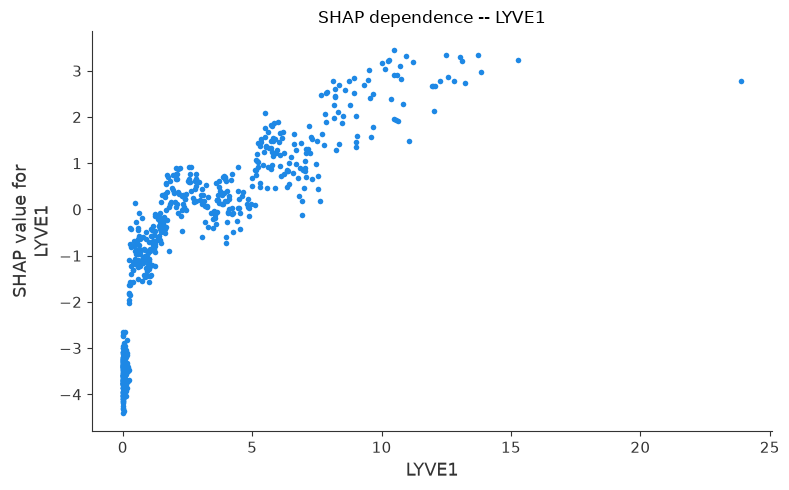

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
shap.dependence_plot(
    "LYVE1", shap_values, X_imputed, feature_names=feature_order,
    interaction_index=None, ax=ax, show=False,
)
ax.set_title("SHAP dependence -- LYVE1")
fig.tight_layout()
fig.savefig(EVAL_CLINICAL_DIR / "shap_dependence_LYVE1.png", dpi=150)
plt.show()


### Three individual waterfalls

In [11]:
idx_pdac = int(np.argmax(np.where(y == 1, raw_margin_pred, -np.inf)))
idx_control = int(np.argmin(np.where(y == 0, raw_margin_pred, np.inf)))
idx_imputed = int(np.argmax(np.where(ca19_9_missing_mask, np.abs(ca19_9_shap), -np.inf)))

examples = [
    ("shap_waterfall_example_0.png", idx_pdac, "most-confident PDAC"),
    ("shap_waterfall_example_1.png", idx_control, "most-confident control"),
    ("shap_waterfall_example_2.png", idx_imputed, "CA19-9 imputed (largest |SHAP| for that feature)"),
]

for fname, i, label in examples:
    print(
        f"{fname}: row {i}, {label}, target_binary={y[i]}, "
        f"raw_margin={raw_margin_pred[i]:.3f}, ca19_9_missing={bool(ca19_9_missing_mask[i])}"
    )


shap_waterfall_example_0.png: row 502, most-confident PDAC, target_binary=1, raw_margin=8.009, ca19_9_missing=False
shap_waterfall_example_1.png: row 381, most-confident control, target_binary=0, raw_margin=-9.284, ca19_9_missing=False
shap_waterfall_example_2.png: row 576, CA19-9 imputed (largest |SHAP| for that feature), target_binary=1, raw_margin=3.441, ca19_9_missing=True


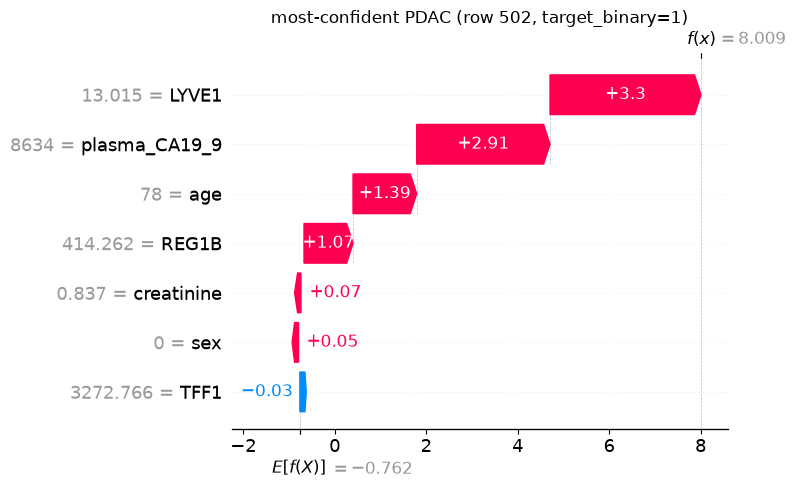

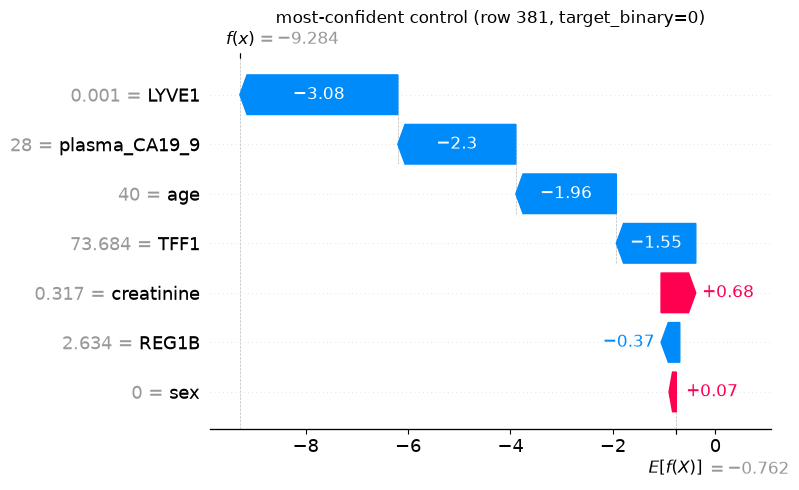

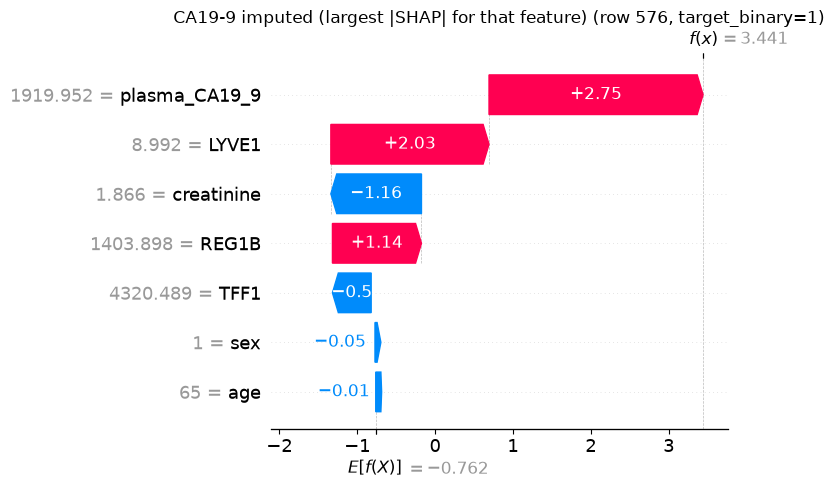

In [12]:
for fname, i, label in examples:
    exp = shap.Explanation(
        values=shap_values[i],
        base_values=expected_value,
        data=X_imputed.iloc[i].to_numpy(),
        feature_names=feature_order,
    )
    fig = plt.figure(figsize=(8, 5))
    shap.plots.waterfall(exp, show=False)
    plt.title(f"{label} (row {i}, target_binary={y[i]})")
    plt.tight_layout()
    plt.savefig(EVAL_CLINICAL_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()


## `explain_tabular` -- single-row explain helper for the dashboard

In [13]:
def explain_tabular(row_df: pd.DataFrame) -> tuple[dict, float]:
    """row_df: 1-row DataFrame with raw (pre-imputation) columns creatinine, LYVE1,
    REG1B, TFF1, plasma_CA19_9 (may be NaN), age, sex. Returns (shap_per_feature, base_value)."""
    assert len(row_df) == 1, "explain_tabular expects exactly one row"
    row_imputed = clinical_imputer.transform(row_df)[feature_order]
    row_shap = explainer.shap_values(row_imputed)
    row_shap = np.asarray(row_shap).reshape(-1)
    return dict(zip(feature_order, row_shap.tolist())), expected_value


# smoke test on a row that had CA19_9 imputed, reusing the raw (pre-imputation) row
_test_row = df.iloc[[idx_imputed]][feature_order]
_shap_per_feature, _base_value = explain_tabular(_test_row)
_reconstructed = _base_value + sum(_shap_per_feature.values())
print(f"explain_tabular smoke test: reconstructed={_reconstructed:.4f}, actual={raw_margin_pred[idx_imputed]:.4f}")
assert abs(_reconstructed - raw_margin_pred[idx_imputed]) < 1e-4


explain_tabular smoke test: reconstructed=3.4414, actual=3.4414


## Outputs

## Robustness check -- does the ranking survive the switch to probability space?

In [ ]:
import copy

clinical_model_for_proba_shap = copy.copy(clinical_model)
clinical_model_for_proba_shap.enable_categorical = False
assert np.array_equal(
    clinical_model.predict_proba(X_imputed), clinical_model_for_proba_shap.predict_proba(X_imputed)
), "shallow copy changed predictions -- aborting, something is wrong"

explainer_proba = shap.TreeExplainer(
    clinical_model_for_proba_shap, data=X_imputed, feature_perturbation="interventional", model_output="probability",
)
shap_values_proba = np.asarray(explainer_proba.shap_values(X_imputed))
if shap_values_proba.ndim == 3:
    shap_values_proba = shap_values_proba[..., -1] if shap_values_proba.shape[-1] == 2 else shap_values_proba[-1]

expected_value_proba = explainer_proba.expected_value
if isinstance(expected_value_proba, (list, np.ndarray)):
    expected_value_proba = np.asarray(expected_value_proba).reshape(-1)[-1]
expected_value_proba = float(expected_value_proba)

raw_proba_pred = clinical_model.predict_proba(X_imputed)[:, 1]
reconstructed_proba = expected_value_proba + shap_values_proba.sum(axis=1)
max_abs_error_proba = float(np.max(np.abs(reconstructed_proba - raw_proba_pred)))
passes_proba = max_abs_error_proba < 1e-3
print(f"Probability-space additivity: {'PASS' if passes_proba else 'FAIL'} (max abs error = {max_abs_error_proba:.6f})")
assert passes_proba, f"Probability-space additivity check FAILED (max abs error {max_abs_error_proba:.6f})"

rank_logodds = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_order).rank(ascending=False)
rank_proba = pd.Series(np.abs(shap_values_proba).mean(axis=0), index=feature_order).rank(ascending=False)

ranking_comparison = pd.DataFrame({
    "mean_abs_shap_logodds": np.abs(shap_values).mean(axis=0),
    "rank_logodds": rank_logodds,
    "mean_abs_shap_proba": np.abs(shap_values_proba).mean(axis=0),
    "rank_proba": rank_proba,
}, index=feature_order).sort_values("rank_logodds")
ranking_comparison["rank_shift"] = ranking_comparison["rank_proba"] - ranking_comparison["rank_logodds"]

spearman_rho = ranking_comparison["rank_logodds"].corr(ranking_comparison["rank_proba"], method="spearman")
print(f"Spearman rank correlation between log-odds ranking and probability-space ranking: {spearman_rho:.4f}")

ranking_comparison_path = RESULTS_CLINICAL_DIR / "shap_ranking_comparison.csv"
ranking_comparison.to_csv(ranking_comparison_path)
print(f"Saved {ranking_comparison_path}")

ranking_comparison

Background dataset has 590 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=590 when initializing the masker.


Probability-space additivity: PASS (max abs error = 0.000000)
Spearman rank correlation between log-odds ranking and probability-space ranking: 0.9643
Saved C:\FYP\results\clinical\shap_ranking_comparison.csv


,mean_abs_shap_logodds,rank_logodds,mean_abs_shap_proba,rank_proba,rank_shift
LYVE1,1.668855,1.0,0.131912,2.0,1.0
plasma_CA19_9,1.292999,2.0,0.158443,1.0,-1.0
creatinine,0.832104,3.0,0.069602,3.0,0.0
age,0.809623,4.0,0.066401,4.0,0.0
TFF1,0.599364,5.0,0.045790,5.0,0.0
REG1B,0.382138,6.0,0.034399,6.0,0.0
sex,0.072649,7.0,0.005075,7.0,0.0
